# Notebook for Noise Diode Plots

# Testing the noise diode ENR response against frequency and set voltage

In [42]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams.update({
    "font.family": "serif"
})

In [43]:
class ENRMeasurement:
    def __init__(self,
                 filepath,
                 voltage):
        self.voltage=voltage
        data = np.genfromtxt(filepath,
                             skip_header=1,
                             delimiter=',')
        self.freqs = data[:,0]
        self.enr = data[:,1]
        self.enr_error = data[:,-1]
        pass

In [44]:
enr_measurement = ENRMeasurement('noise_diode_enr/old_noise_diode/old_23.9v.csv', 23.9)
enr_measurement.enr

array([ 9.11,  9.66, 11.29, 11.92, 11.73, 10.37, 10.04, 10.08, 10.17,
       10.31, 10.48])

In [45]:
old_nd_measurements = [
    ENRMeasurement('noise_diode_enr/old_noise_diode/old_23.9v.csv', 23.9),
    ENRMeasurement('noise_diode_enr/old_noise_diode/old_24v.csv', 24),
    ENRMeasurement('noise_diode_enr/old_noise_diode/old_24.2v.csv', 24.2),
    ENRMeasurement('noise_diode_enr/old_noise_diode/old_24.4v.csv', 24.4),
    ENRMeasurement('noise_diode_enr/old_noise_diode/old_28v.csv', 28)
]

new_nd_measurements = [
    ENRMeasurement('noise_diode_enr/new_noise_diode/new_23.9v.csv', 23.9),
        ENRMeasurement('noise_diode_enr/new_noise_diode/new_24v.csv', 24),
        ENRMeasurement('noise_diode_enr/new_noise_diode/new_24.1v.csv', 24.1),
        ENRMeasurement('noise_diode_enr/new_noise_diode/new_24.2v.csv', 24.2),
        ENRMeasurement('noise_diode_enr/new_noise_diode/new_24.3v.csv', 24.3)
]

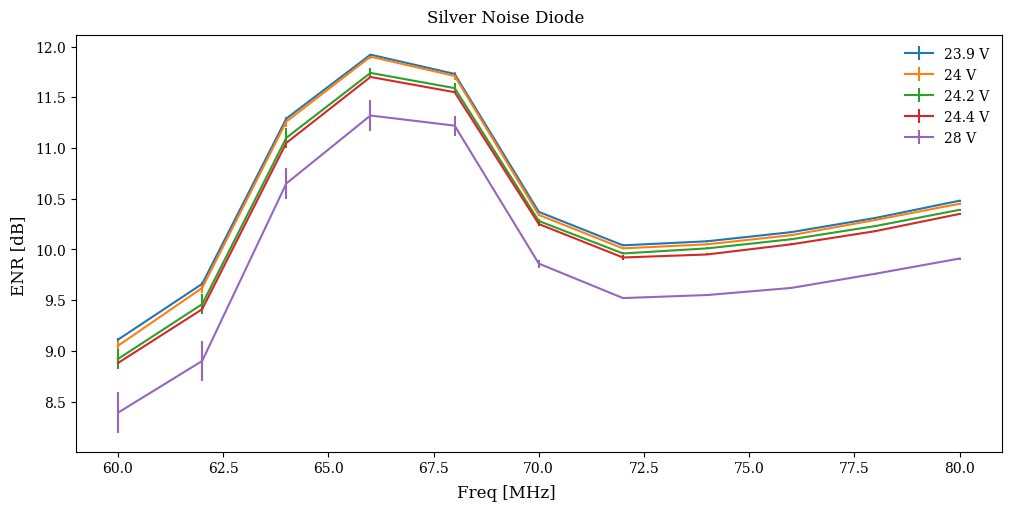

In [46]:
fig, axes = plt.subplots(layout='constrained')

for meas in old_nd_measurements:
    axes.errorbar(x=meas.freqs, y=meas.enr, yerr=meas.enr_error, label=f'{meas.voltage} V')
axes.legend(frameon=False)
fig.supxlabel(r'Freq [MHz]')
fig.supylabel(r'ENR [dB]')
fig.suptitle('Silver Noise Diode')
plt.show()

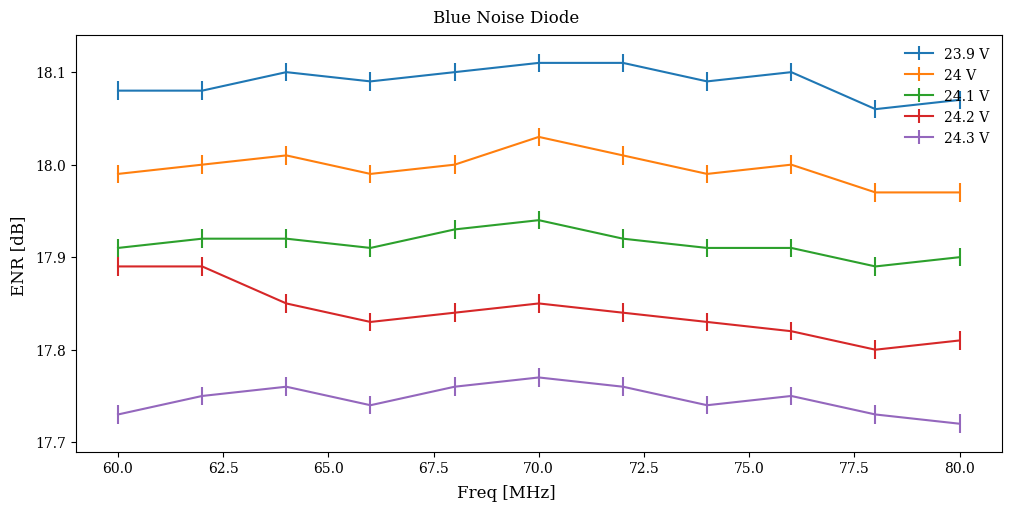

In [47]:
fig, axes = plt.subplots(layout='constrained')

for meas in new_nd_measurements:
    axes.errorbar(x=meas.freqs, y=meas.enr, yerr=meas.enr_error, label=f'{meas.voltage} V')
axes.legend(frameon=False)
fig.supxlabel(r'Freq [MHz]')
fig.supylabel(r'ENR [dB]')
fig.suptitle('Blue Noise Diode')
plt.show()

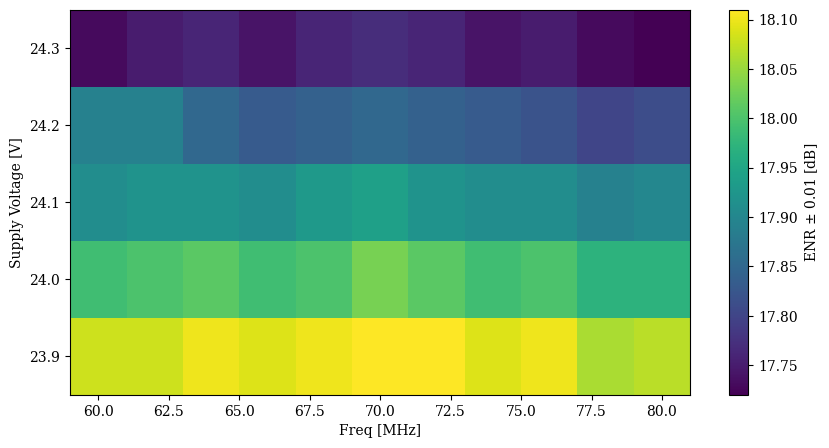

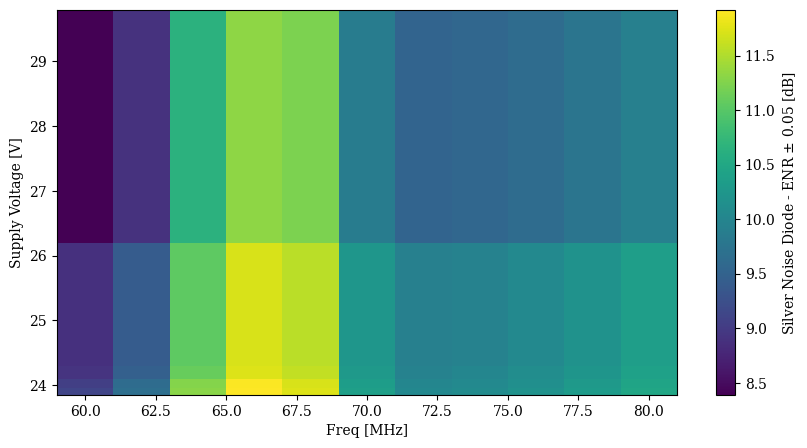

In [48]:
new_enr = np.array([meas.enr for meas in new_nd_measurements])
new_freqs = new_nd_measurements[0].freqs
new_volt = np.array([meas.voltage for meas in new_nd_measurements])
plt.pcolormesh(new_freqs, new_volt, new_enr)
plt.colorbar(label=r'ENR $\pm$ 0.01 [dB]')
plt.ylabel('Supply Voltage [V]')
plt.xlabel('Freq [MHz]')
plt.show()

new_enr = np.array([meas.enr for meas in old_nd_measurements])
new_freqs = old_nd_measurements[0].freqs
new_volt = np.array([meas.voltage for meas in old_nd_measurements])
plt.pcolormesh(new_freqs, new_volt, new_enr)
plt.colorbar(label=r'Silver Noise Diode - ENR $\pm$ 0.05 [dB]')
plt.ylabel('Supply Voltage [V]')
plt.xlabel('Freq [MHz]')
plt.show()